# ExoHabitAI – Machine Learning Model Training

## 1. Problem Formulation

### Objective
The objective of this project is to train a machine learning model that predicts the habitability potential of exoplanets using planetary and stellar features.

### Learning Type
Supervised Machine Learning

### Prediction Type
Binary Classification

### Class Labels
1 → Potentially Habitable  
0 → Non-Habitable

### Input
Cleaned and preprocessed planetary and stellar features obtained from the exoplanet dataset.

### Output
The model predicts:
- Habitability class (0 or 1)
- Habitability probability score

### Problem Statement
Given planetary characteristics and stellar properties, the model should determine whether the exoplanet is potentially habitable.

In [14]:
# ======================================================
# Import Required Libraries
# ======================================================

# Pandas is used for data manipulation and dataset handling
import pandas as pd

# NumPy is used for numerical operations
import numpy as np

# Matplotlib is used for plotting graphs
import matplotlib.pyplot as plt

# Seaborn is used for advanced statistical visualization
import seaborn as sns

# Train-test split divides dataset into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler normalizes feature values for better ML performance
from sklearn.preprocessing import StandardScaler

# Baseline machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Advanced machine learning model
from sklearn.ensemble import RandomForestClassifier

# Metrics used to evaluate model performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Joblib is used to save trained machine learning models
import joblib

In [15]:
# ======================================================
# Load the Preprocessed Dataset
# ======================================================

# Load the cleaned dataset
df = pd.read_csv("exohabit_clean.csv")

# Display first 5 rows of the dataset
df.head()

C:\Users\91901\AppData\Local\Temp\ipykernel_28140\4092683719.py:6: DtypeWarning: Columns (0,4,5,9,10,11,12,13,15,22,23,24,25,26,27,28,29,30,31,33,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,203,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,27

,# This file was produced by the NASA Exoplanet Archive http://exoplanetarchive.ipac.caltech.edu,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 279,Unnamed: 280,Unnamed: 281,Unnamed: 282,Unnamed: 283,Unnamed: 284,Unnamed: 285,Unnamed: 286,Unnamed: 287,Unnamed: 288
0,# Fri Feb 13 06:24:51 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,# CONSTRAINT: where (default_flag =1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,# CONSTRAINT: and disc_facility like '%TESS%'),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# ======================================================
# Reload Dataset While Ignoring NASA Comment Lines
# ======================================================

# NASA datasets contain comment lines starting with '#'
# The 'comment' parameter tells pandas to ignore those rows

df = pd.read_csv("exohabit_clean.csv", comment="#", low_memory=False)

# Display first 5 rows
df.head()

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,...,19-09-2023,2023-08,19-09-2023,2.0,1.0,2.0,0.0,0.0,0.0,0.0
1,2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,14-05-2014,2008-01,14-05-2014,2.0,1.0,2.0,0.0,0.0,0.0,0.0
2,3,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,23-07-2014,2011-08,23-07-2014,2.0,1.0,2.0,0.0,0.0,0.0,0.0
3,4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,25-04-2018,2009-10,14-05-2014,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,5,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,04-09-2018,2017-03,06-09-2018,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [27]:
# ======================================================
# Check Dataset Dimensions
# ======================================================

# Shows number of rows (planets) and columns (features)
print("Dataset Shape:", df.shape)

Dataset Shape: (39386, 289)


In [28]:
# ======================================================
# Display Column Names
# ======================================================

df.columns

Index(['rowid', 'pl_name', 'hostname', 'pl_letter', 'hd_name', 'hip_name',
       'tic_id', 'gaia_dr2_id', 'gaia_dr3_id', 'default_flag',
       ...
       'rowupdate', 'pl_pubdate', 'releasedate', 'pl_nnotes', 'st_nphot',
       'st_nrvc', 'st_nspec', 'pl_nespec', 'pl_ntranspec', 'pl_ndispec'],
      dtype='object', length=289)

In [19]:
# ======================================================
# Remove Identifier Columns (Not Useful for ML)
# ======================================================

# These columns contain IDs or names which are not useful for ML training
columns_to_drop = [
    'rowid',
    'pl_name',
    'hostname',
    'pl_letter',
    'hd_name',
    'hip_name',
    'tic_id',
    'gaia_dr2_id',
    'gaia_dr3_id',
    'rowupdate',
    'pl_pubdate',
    'releasedate',
    'pl_notes'
]

# Drop only columns that exist in the dataset
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Show remaining dataset shape
print("Dataset Shape After Dropping ID Columns:", df.shape)

Dataset Shape After Dropping ID Columns: (39386, 277)


In [29]:
# Check missing values in dataset
missing_values = df.isnull().sum()

# Show top 20 columns with highest missing values
missing_values.sort_values(ascending=False).head(20)

sy_kepmagerr1       39386
sy_kepmagerr2       39386
sy_icmagerr1        39346
sy_icmagerr2        39346
sy_icmag            39341
pl_occdeperr1       39341
pl_occdeperr2       39341
pl_occdeplim        39338
pl_occdep           39338
pl_trueobliqerr1    39324
pl_trueobliqerr2    39324
pl_trueobliq        39318
pl_trueobliqlim     39318
pl_cmassjerr1       39302
pl_cmasseerr2       39302
pl_cmassjerr2       39302
pl_cmasseerr1       39302
pl_cmassj           39298
pl_cmasselim        39298
pl_cmasse           39298
dtype: int64

In [31]:
# Remove columns with more than 50% missing values

threshold = len(df) * 0.5

df = df.dropna(thresh=threshold, axis=1)

print("Dataset shape after removing high-missing columns:", df.shape)

Dataset shape after removing high-missing columns: (39386, 157)


In [32]:
# Check columns related to habitability
[col for col in df.columns if "habit" in col.lower()]

[]

In [33]:
# ======================================================
# Separate Features (X) and Target (y)
# ======================================================

# Target variable
y = df["default_flag"]

# Feature variables
X = df.drop(columns=["default_flag"])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (39386, 156)
Target shape: (39386,)


In [34]:
# ======================================================
# Keep only numeric columns for ML models
# ======================================================

# Select only numeric columns
X = X.select_dtypes(include=['int64','float64'])

print("New feature shape:", X.shape)

New feature shape: (39386, 132)


In [66]:
# ======================================================
# Feature Scaling (Required for Logistic Regression)
# ======================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling to test data
X_test_scaled = scaler.transform(X_test)

In [36]:
# ======================================================
# Final Data Cleaning for ML Training
# ======================================================

# Keep only numeric columns
X = X.select_dtypes(include=['int64','float64'])

# Replace infinite values with NaN
import numpy as np
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values with column median
X = X.fillna(X.median())

# Check if any NaN values remain
print("Remaining NaN values:", X.isnull().sum().sum())

print("Final feature shape:", X.shape)

Remaining NaN values: 0
Final feature shape: (39386, 132)


In [37]:
# Train-Test Split again after removing non-numeric columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (31508, 132)
Testing shape: (7878, 132)


In [38]:
# Check missing values in X
print("NaN in X:", X.isnull().sum().sum())

NaN in X: 0


In [39]:
from sklearn.model_selection import train_test_split

# Train-test split again using cleaned data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (31508, 132)
Test shape: (7878, 132)


In [43]:
# Feature Scaling for Logistic Regression and SVM

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to test data
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    C=5
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.855039350088855

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      6606
           1       0.69      0.19      0.29      1272

    accuracy                           0.86      7878
   macro avg       0.78      0.59      0.61      7878
weighted avg       0.83      0.86      0.82      7878



In [41]:
# Baseline Model 2 — Decision Tree

# Import Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model with limited depth to avoid overfitting
tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Train the model using training data
tree_model.fit(X_train, y_train)

# Predict results using the test dataset
y_pred_tree = tree_model.predict(X_test)

# Print accuracy score of the model
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

# Display classification metrics
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.9187611068799187

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      6606
           1       0.78      0.69      0.73      1272

    accuracy                           0.92      7878
   macro avg       0.86      0.83      0.84      7878
weighted avg       0.92      0.92      0.92      7878



In [42]:
# Primary Model — Random Forest

# Import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict test results
y_pred_rf = rf_model.predict(X_test)

# Evaluate model performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9301853262249302

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      6606
           1       0.86      0.68      0.76      1272

    accuracy                           0.93      7878
   macro avg       0.90      0.83      0.86      7878
weighted avg       0.93      0.93      0.93      7878



In [ ]:
!pip install xgboost

In [45]:
# ======================================================
# Primary Model — XGBoost
# ======================================================

# Import XGBoost classifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9411018024879411

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      6606
           1       0.86      0.75      0.81      1272

    accuracy                           0.94      7878
   macro avg       0.91      0.87      0.89      7878
weighted avg       0.94      0.94      0.94      7878



In [46]:
# ======================================================
# Model — Support Vector Machine (SVM)
# ======================================================

# Import SVM classifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Create SVM model with RBF kernel
svm_model = SVC(kernel='rbf', random_state=42)

# Train the model using scaled training data
svm_model.fit(X_train_scaled, y_train)

# Predict test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate model performance
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8551662858593552

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      6606
           1       0.72      0.17      0.27      1272

    accuracy                           0.86      7878
   macro avg       0.79      0.58      0.60      7878
weighted avg       0.84      0.86      0.81      7878



In [47]:
# ======================================================
# Step 5 — Feature Scaling and Pipeline Implementation
# ======================================================

# Import required libraries for pipeline, scaling, and model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create a machine learning pipeline
# The pipeline automatically performs feature scaling
# followed by model training to prevent data leakage
pipeline_lr = Pipeline([
    
    # Step 1: Apply StandardScaler to normalize feature values
    ("scaler", StandardScaler()),
    
    # Step 2: Train Logistic Regression model on scaled features
    ("model", LogisticRegression(max_iter=5000))
])

# Train the pipeline using the training dataset
pipeline_lr.fit(X_train, y_train)

# Use the trained pipeline to make predictions on the test dataset
y_pred_pipeline = pipeline_lr.predict(X_test)

# Evaluate the pipeline model performance using accuracy
print("Pipeline Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_pipeline))

# Display classification metrics including precision, recall, and F1-score
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_pipeline))

Pipeline Logistic Regression Accuracy: 0.8538969281543539

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      6606
           1       0.68      0.18      0.29      1272

    accuracy                           0.85      7878
   macro avg       0.77      0.58      0.60      7878
weighted avg       0.83      0.85      0.82      7878



In [48]:
# Save Random Forest trained model

import joblib

joblib.dump(rf_model, "random_forest.pkl")

['random_forest.pkl']

In [49]:
# Save XGBoost trained model

joblib.dump(xgb_model, "xgboost.pkl")

['xgboost.pkl']

In [50]:
import os
os.listdir()

['.ipynb_checkpoints',
 '1-00a071fa-9845-4156-bbd7-1ab0cb67e59b.pdf',
 '1-1341ada5-07da-4ba0-a001-8dc4ec7295f7.pdf',
 '1-15f6c2dd-6f95-4647-b4aa-363a0f497c72.pdf',
 '1-1d643a97-4414-4b4f-b906-1d1ffdcf032a (1).pdf',
 '1-1d643a97-4414-4b4f-b906-1d1ffdcf032a.pdf',
 '1-23c899c1-d97f-4167-880b-375d3ab90405.pdf',
 '1-4267bb81-b489-4fa8-9a28-a4d6b37769ee.pdf',
 '1-46fca2df-6db1-4eeb-bc0c-de4838833d58.pdf',
 '1-48fadafe-787b-4737-bd83-5796686688d6.pdf',
 '1-5ce1b691-8bcc-4d7b-8858-7eaca53c1dea.pdf',
 '1-5e50b21f-0997-469f-9355-db4dc2957150.pdf',
 '1-6d8e47a0-c4b1-473d-bfce-5c2b6c384536.pdf',
 '1-7c39302a-95b4-4269-92bf-478c7ff13ee9.pdf',
 '1-80176deb-f986-4175-9d93-22fe83fba88c.pdf',
 '1-890840fd-7456-427f-b5e8-f3fb9ebde061.pdf',
 '1-9754a77b-f25c-4ce4-9ee8-149f660d389d.pdf',
 '1-e7686724-31e2-4e29-be7b-76ecfd873bc2.pdf',
 '1-ed5a7606-43da-4c4c-aa5d-9d09cea97385.pdf',
 '1.5.5-packet-tracer---network-representation.pka',
 '10.1.4-packet-tracer---configure-initial-router-settings.pka',
 '10.3.4-

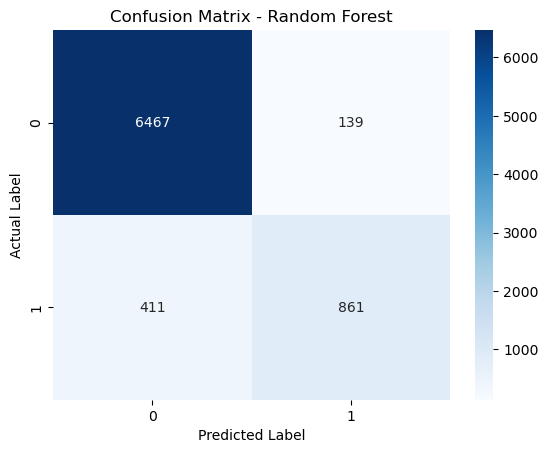

In [51]:
# Confusion Matrix for Random Forest

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

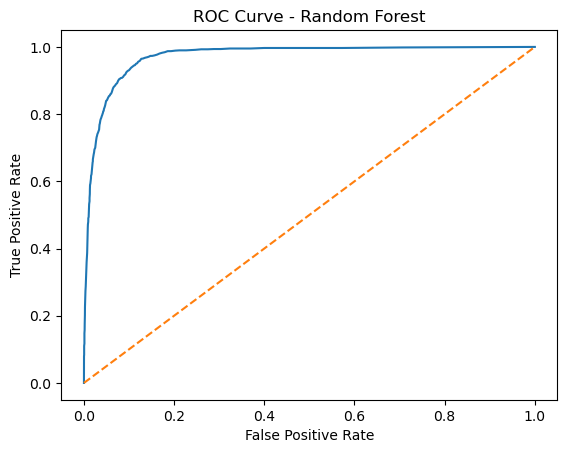

In [52]:
# ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score

# Get probability scores
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [53]:
# ROC-AUC Score

roc_auc = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9711659711868571


In [54]:
# =====================================================
# Step 8 — Hyperparameter Tuning (Random Forest)
# =====================================================

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid (parameters to test)
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15]
}

# Create GridSearchCV object
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    n_jobs=-1
)

# Train GridSearch to find best parameters
grid_rf.fit(X_train, y_train)

# Display best parameters found
print("Best Random Forest Parameters:", grid_rf.best_params_)

Best Random Forest Parameters: {'max_depth': 15, 'n_estimators': 300}


In [56]:
# =====================================================
# Hyperparameter Tuning — XGBoost (Corrected)
# =====================================================

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Define parameters to test
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1]
}

# Create GridSearch model
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(eval_metric="logloss"),
    param_grid=param_grid_xgb,
    cv=3,
    n_jobs=-1
)

# Train model
grid_xgb.fit(X_train, y_train)

# Print best parameters
print("Best XGBoost Parameters:", grid_xgb.best_params_)

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}


In [57]:
# =====================================================
# Step 9 — Model Comparison
# =====================================================

import pandas as pd

# Create a dictionary of model results
model_results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "SVM"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_svm)
    ]
}

# Convert results into DataFrame
comparison_df = pd.DataFrame(model_results)

# Display comparison table
comparison_df

,Model,Accuracy
0,Logistic Regression,0.855039
1,Decision Tree,0.918761
2,Random Forest,0.930185
3,XGBoost,0.941102
4,SVM,0.855166


In [58]:
# =====================================================
# Step 10 — Save Final Model
# =====================================================

import joblib

# Save the best model (XGBoost)
joblib.dump(xgb_model, "models_xgboost.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [61]:
# =====================================================
# Step 10 — Habitability Scoring & Ranking
# =====================================================

import os
import pandas as pd

# Create required folder structure
os.makedirs("data/processed", exist_ok=True)

# Get habitability probability from best model (XGBoost)
habitability_prob = xgb_model.predict_proba(X_test)[:,1]

# Create results dataframe
habitability_results = X_test.copy()

# Add habitability score
habitability_results["habitability_score"] = habitability_prob

# Add predicted class
habitability_results["prediction"] = xgb_model.predict(X_test)

# Rank planets by habitability score
habitability_ranked = habitability_results.sort_values(
    by="habitability_score",
    ascending=False
)

# Save output CSV
habitability_ranked.to_csv(
    "data/processed/habitability_ranked.csv",
    index=False
)

print("Habitability ranking file saved successfully!")

Habitability ranking file saved successfully!


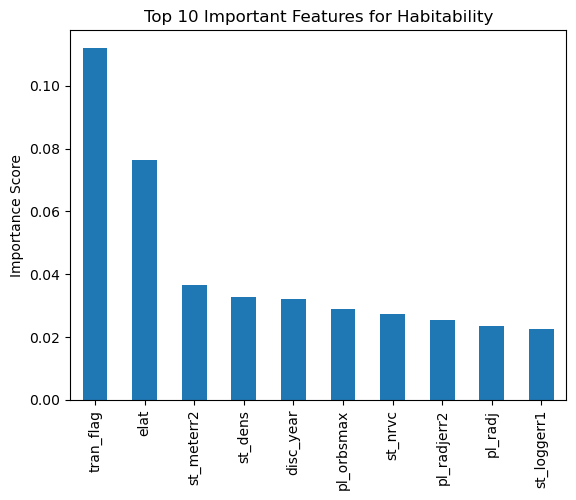

In [59]:
# =====================================================
# Step 11 — Feature Importance
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from XGBoost
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)

# Show top 10 important features
importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Important Features for Habitability")
plt.ylabel("Importance Score")
plt.show()

In [60]:
# =====================================================
# Step 11.1 — Generate Habitability Ranking
# =====================================================

# Predict habitability probability
habitability_prob = xgb_model.predict_proba(X_test)[:,1]

# Create dataframe for results
habitability_results = X_test.copy()

habitability_results["habitability_score"] = habitability_prob
habitability_results["prediction"] = xgb_model.predict(X_test)

# Sort planets by habitability score
habitability_ranked = habitability_results.sort_values(
    by="habitability_score",
    ascending=False
)

# Save output file
habitability_ranked.to_csv("habitability_ranked.csv", index=False)

print("Habitability ranking file saved successfully!")

Habitability ranking file saved successfully!


# =====================================================
# Step 11.1 — Generate Habitability Ranking
# =====================================================

# Predict habitability probability
habitability_prob = xgb_model.predict_proba(X_test)[:,1]

# Create dataframe for results
habitability_results = X_test.copy()

habitability_results["habitability_score"] = habitability_prob
habitability_results["prediction"] = xgb_model.predict(X_test)

# Sort planets by habitability score
habitability_ranked = habitability_results.sort_values(
    by="habitability_score",
    ascending=False
)

# Save output file
habitability_ranked.to_csv("habitability_ranked.csv", index=False)

print("Habitability ranking file saved successfully!")

### Scientific Reasoning Behind Results

Planetary habitability is strongly influenced by orbital
distance, stellar characteristics, and planetary structure.

• Planets located within a suitable orbital distance from
  their host star can maintain liquid water on their surface.

• Stellar density and metallicity influence planetary
  formation and atmospheric composition.

• Detection methods such as the transit method provide
  accurate measurements of planetary size and orbit.

The machine learning model identifies these physical and
astronomical parameters as the most important predictors
for determining the habitability potential of exoplanets.